# 02 - Results Folder Dashboard

Auto-discovers all runs under `../results` and visualizes available metrics/csv outputs.


In [43]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


In [44]:
results_root = Path('../results').resolve()
run_dirs = sorted([p for p in results_root.iterdir() if p.is_dir()]) if results_root.exists() else []

rows = []
for run_dir in run_dirs:
    rows.append({
        'run_name': run_dir.name,
        'has_metrics_json': (run_dir / 'metrics.json').exists(),
        'has_rollout_predictions_csv': (run_dir / 'rollout_predictions.csv').exists(),
        'has_cv_vs_pratio_csv': (run_dir / 'cv_vs_pratio.csv').exists(),
        'has_train_stats_pt': (run_dir / 'train_stats.pt').exists(),
        'has_rollout_ckpt_dir': (run_dir / 'rollout_checkpoints').exists(),
    })

discovery_df = pd.DataFrame(rows)
print(f'Results root: {results_root}')
print(f'Discovered runs: {len(discovery_df)}')
discovery_df


Results root: /home/alexz/Documents/course_project/results
Discovered runs: 3


,run_name,has_metrics_json,has_rollout_predictions_csv,has_cv_vs_pratio_csv,has_train_stats_pt,has_rollout_ckpt_dir
0,hybrid,True,True,True,True,True
1,spatial,True,True,True,True,True
2,transformer,True,True,True,True,True


In [45]:
metrics_rows = []
for run_dir in run_dirs:
    metrics_path = run_dir / 'metrics.json'
    if not metrics_path.exists():
        continue
    data = json.loads(metrics_path.read_text())
    data['run_name'] = run_dir.name
    metrics_rows.append(data)

metrics_df = pd.DataFrame(metrics_rows)
if metrics_df.empty:
    print('No metrics.json files found yet.')
else:
    cols = [
        c for c in [
            'run_name',
            'model_type',
            'rollout_r2',
            'rollout_pearson_r',
            'rollout_pos_mse',
            'best_rollout_epoch',
            'best_rollout_r2',
            'selected_checkpoint',
        ] if c in metrics_df.columns
    ]
    display(metrics_df[cols].sort_values('rollout_r2', ascending=False, na_position='last'))


,run_name,model_type,rollout_r2,rollout_pearson_r,rollout_pos_mse,best_rollout_epoch,best_rollout_r2,selected_checkpoint
1,spatial,spatial,0.578433,0.840073,0.000187,90,0.578433,../results/spatial/rollout_checkpoints/epoch_0...
0,hybrid,hybrid,0.538030,0.756333,0.000152,190,0.538030,../results/hybrid/rollout_checkpoints/epoch_01...
2,transformer,spatial_transformer,0.424050,0.715087,0.000244,200,0.424050,../results/transformer/rollout_checkpoints/epo...


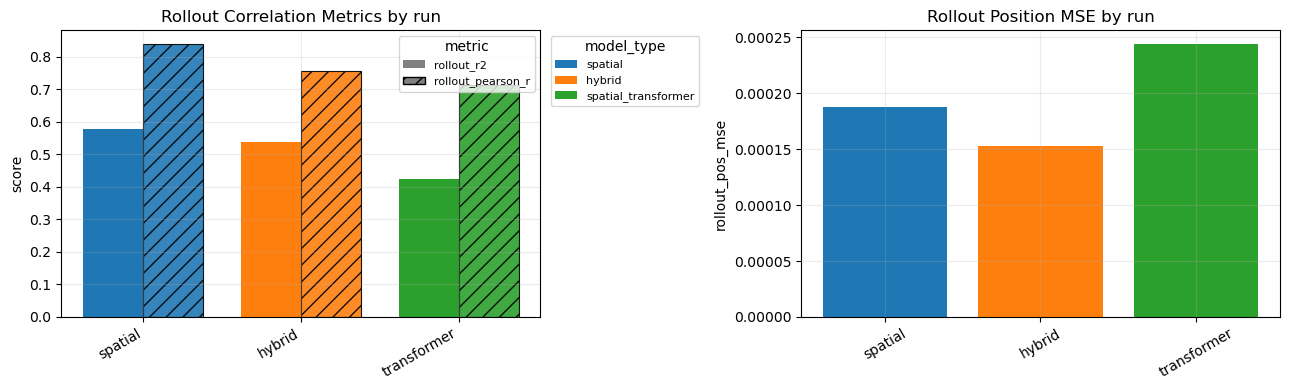

In [46]:
if metrics_df.empty:
    print('Skipping metrics plots (no metrics.json).')
else:
    plot_df = metrics_df.copy()
    plot_df = plot_df.sort_values('rollout_r2', ascending=False, na_position='last').reset_index(drop=True)
    x = np.arange(len(plot_df))
    labels = plot_df['run_name'].tolist()

    # Consistent color per model; metric type encoded by hatch/edge style.
    if 'model_type' in plot_df.columns:
        model_order = pd.unique(plot_df['model_type'].fillna('unknown'))
    else:
        model_order = ['unknown']
    cmap = plt.get_cmap('tab10')
    model_color = {m: cmap(i % 10) for i, m in enumerate(model_order)}
    colors = [model_color.get(m if pd.notna(m) else 'unknown', cmap(0)) for m in plot_df.get('model_type', pd.Series(['unknown'] * len(plot_df)))]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    width = 0.38
    r2_vals = plot_df['rollout_r2'].to_numpy(dtype=float)
    axes[0].bar(x - width/2, r2_vals, width=width, color=colors, label='rollout_r2')

    if 'rollout_pearson_r' in plot_df.columns:
        pearson_vals = plot_df['rollout_pearson_r'].to_numpy(dtype=float)
        # Same color as the matching run; dashed-like style via hatch.
        axes[0].bar(
            x + width/2,
            pearson_vals,
            width=width,
            color=colors,
            edgecolor='black',
            linewidth=0.8,
            hatch='//',
            alpha=0.9,
            label='rollout_pearson_r',
        )

    axes[0].set_title('Rollout Correlation Metrics by run')
    axes[0].set_ylabel('score')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=30, ha='right')
    axes[0].grid(alpha=0.25)

    # Legend for metrics (R2 vs Pearson)
    from matplotlib.patches import Patch
    metric_handles = [Patch(facecolor='gray', label='rollout_r2')]
    if 'rollout_pearson_r' in plot_df.columns:
        metric_handles.append(Patch(facecolor='gray', edgecolor='black', hatch='//', label='rollout_pearson_r'))
    metric_legend = axes[0].legend(handles=metric_handles, fontsize=8, loc='best', title='metric')
    axes[0].add_artist(metric_legend)

    # Legend for model colors
    if 'model_type' in plot_df.columns:
        color_handles = [Patch(facecolor=model_color[m], label=m) for m in model_order]
        axes[0].legend(handles=color_handles, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1.0), title='model_type')

    axes[1].bar(labels, plot_df['rollout_pos_mse'], color=colors)
    axes[1].set_title('Rollout Position MSE by run')
    axes[1].set_ylabel('rollout_pos_mse')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


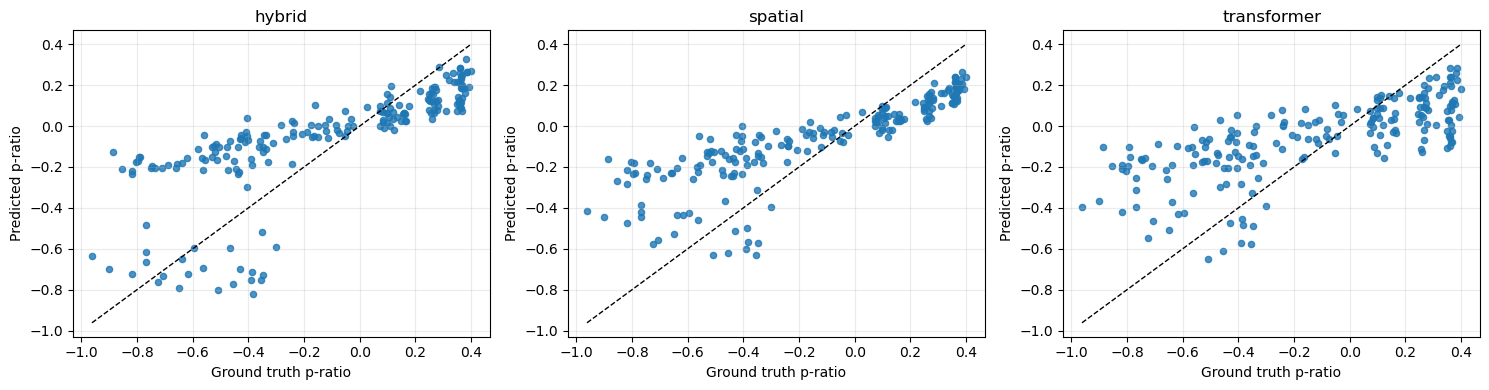

In [47]:
rollout_runs = {}
for run_dir in run_dirs:
    p = run_dir / 'rollout_predictions.csv'
    if not p.exists() or p.stat().st_size == 0:
        continue
    df = pd.read_csv(p)
    if len(df) == 0:
        continue
    rollout_runs[run_dir.name] = df

if not rollout_runs:
    print('No rollout_predictions.csv files available.')
else:
    n = len(rollout_runs)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

    for ax, (run_name, df) in zip(axes.ravel(), rollout_runs.items()):
        x = df['target_rollout_sides_p_ratio'].to_numpy()
        y = df['pred_rollout_p_ratio'].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        x = x[m]
        y = y[m]

        ax.scatter(x, y, s=20, alpha=0.8)
        if len(x) > 0:
            lo = float(min(x.min(), y.min()))
            hi = float(max(x.max(), y.max()))
            ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)

        ax.set_title(run_name)
        ax.set_xlabel('Ground truth p-ratio')
        ax.set_ylabel('Predicted p-ratio')
        ax.grid(alpha=0.25)

    for ax in axes.ravel()[len(rollout_runs):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

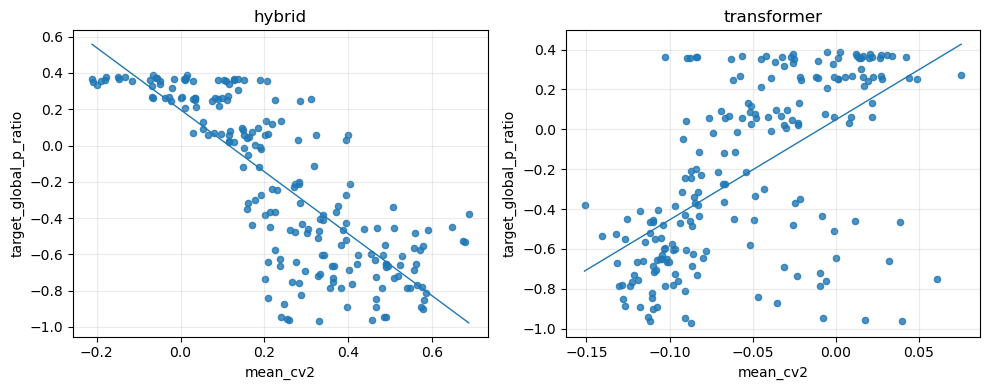

In [48]:
cv_runs = {}
for run_dir in run_dirs:
    p = run_dir / 'cv_vs_pratio.csv'
    if not p.exists() or p.stat().st_size == 0:
        continue
    df = pd.read_csv(p)
    if len(df) == 0 or 'mean_cv2' not in df.columns:
        continue
    cv_runs[run_dir.name] = df

if not cv_runs:
    print('No cv_vs_pratio.csv files with mean_cv2 found.')
else:
    n = len(cv_runs)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

    for ax, (run_name, df) in zip(axes.ravel(), cv_runs.items()):
        x = df['mean_cv2'].to_numpy()
        y = df['target_global_p_ratio'].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        x = x[m]
        y = y[m]

        ax.scatter(x, y, s=20, alpha=0.8)
        if len(x) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            xx = np.linspace(x.min(), x.max(), 100)
            ax.plot(xx, slope * xx + intercept, linewidth=1)

        ax.set_title(run_name)
        ax.set_xlabel('mean_cv2')
        ax.set_ylabel('target_global_p_ratio')
        ax.grid(alpha=0.25)

    for ax in axes.ravel()[len(cv_runs):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


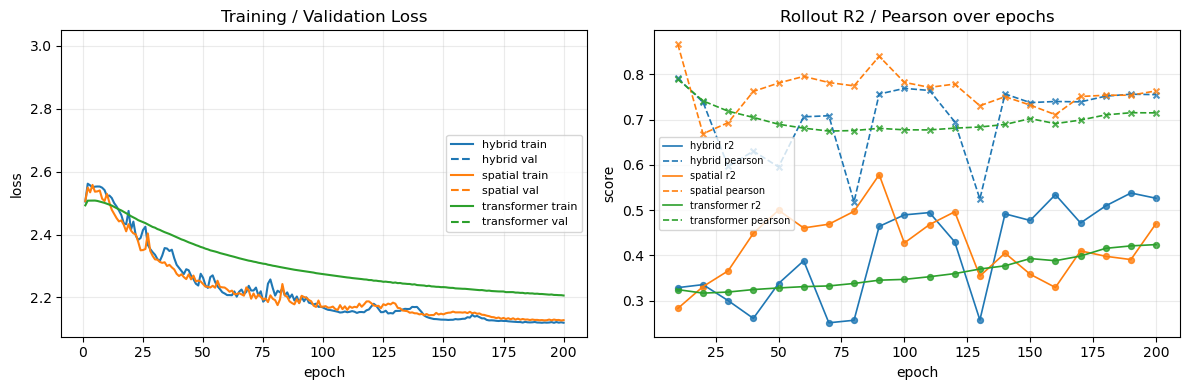

In [49]:
stats_rows = []
for run_dir in run_dirs:
    p = run_dir / 'train_stats.pt'
    if not p.exists():
        continue
    stats = torch.load(p, map_location='cpu', weights_only=False)
    if not isinstance(stats, dict) or 'epoch' not in stats:
        continue
    n = len(stats['epoch'])
    for i, epoch in enumerate(stats['epoch']):
        stats_rows.append({
            'run_name': run_dir.name,
            'epoch': epoch,
            'train_loss': stats.get('loss', [None]*n)[i],
            'val_loss': stats.get('val_loss', [None]*n)[i],
            'rollout_r2': stats.get('rollout_r2', [None]*n)[i],
            'rollout_pearson_r': stats.get('rollout_pearson_r', [None]*n)[i],
        })

stats_df = pd.DataFrame(stats_rows)
if stats_df.empty:
    print('No train_stats.pt files found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    run_names = list(stats_df['run_name'].dropna().unique())
    cmap = plt.get_cmap('tab10')
    run_color = {name: cmap(j % 10) for j, name in enumerate(run_names)}

    for run_name, g in stats_df.groupby('run_name'):
        color = run_color.get(run_name, None)
        axes[0].plot(g['epoch'], g['train_loss'], label=f'{run_name} train', color=color)
        if g['val_loss'].notna().any():
            axes[0].plot(g['epoch'], g['val_loss'], linestyle='--', label=f'{run_name} val', color=color)

        if g['rollout_r2'].notna().any():
            gg = g[g['rollout_r2'].notna()]
            axes[1].plot(gg['epoch'], gg['rollout_r2'], linewidth=1.2, label=f'{run_name} r2', color=color, linestyle='-')
            axes[1].scatter(gg['epoch'], gg['rollout_r2'], s=18, alpha=0.8, color=color, marker='o')

        if 'rollout_pearson_r' in g.columns and g['rollout_pearson_r'].notna().any():
            gp = g[g['rollout_pearson_r'].notna()]
            axes[1].plot(gp['epoch'], gp['rollout_pearson_r'], linewidth=1.2, linestyle='--', label=f'{run_name} pearson', color=color)
            axes[1].scatter(gp['epoch'], gp['rollout_pearson_r'], s=18, alpha=0.8, marker='x', color=color)

    axes[0].set_title('Training / Validation Loss')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].set_title('Rollout R2 / Pearson over epochs')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('score')
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()
